# ATiG 2026: LT-FH exercise using ltpred — worked answers

## What you will learn

The [ltpred tutorial](https://bvilhjal.github.io/ltpred/tutorial/) builds a
simulated register whose genetic liability is known, then scores every person
from family history, and ends by listing shortcuts it never measured. In this
exercise you measure two of them on the same register: what a wrong
liability-scale heritability does to the score (Part A), and how far a
posterior mean genetic liability is from a disease risk (Part B). Part C
estimates the heritability from the register itself with a tetrachoric
correlation.

Everything is compared against the true genetic liability the simulation drew;
no real data are used. Budget one hour for Parts A and B; Part C is homework.

Before running each part, write down what you expect; afterwards, explain one
checkpoint number in your own words. Keep code and answers in this notebook.
Your final product is the Q10 note distinguishing what the score shows from
what it cannot establish.

The model is LT-FH++ ([Pedersen et al. 2022](https://doi.org/10.1016/j.ajhg.2022.01.009)),
which extends LT-FH ([Hujoel et al. 2020](https://doi.org/10.1038/s41588-020-0613-6))
with age of onset. ADuLT ([Pedersen et al. 2023](https://doi.org/10.1038/s41467-023-41210-z))
is the same personalised construction without family history. The scores in this
exercise are computed with the deterministic Pearson–Aitken engine of PA-FGRS
([Dybdahl Krebs et al. 2024](https://doi.org/10.1016/j.ajhg.2024.09.009)). Across
five psychiatric disorders, PA-FGRS and polygenic scores were weakly correlated yet
complementary ([Dybdahl Krebs et al. 2026](https://doi.org/10.1016/j.ajhg.2025.11.016)),
as two noisy estimates of one additive genetic liability should be; Part B's
ceiling shows the same logic from the other side. ltpred's
[algorithm page](https://bvilhjal.github.io/ltpred/algorithm/) states the model and its
[connection to selection-index prediction](https://bvilhjal.github.io/ltpred/algorithm/#connection-to-selection-index-and-blup).


## Setup

Python 3.9 or newer with NumPy and SciPy, and ltpred — not yet on PyPI, so
install it from source. The commands are the same on Windows, macOS and Linux;
no compiler and no R are needed (the worked answers also need Matplotlib):

```bash
git clone https://github.com/bvilhjal/ltpred.git
cd ltpred
pip install -e ".[fast]"      # plain  pip install -e .  works too; numba only speeds it up
```

No data files either: Part 0 rebuilds the tutorial register from fixed seeds,
so a fresh session is enough — you do not need the tutorial still open. Parts
A and B run in about a minute; Part C factorises a 10,000-person kinship
matrix and needs a few GB of memory. Executed with ltpred 0.7.0 (commit `2d85ce9`); the printouts
are identical under NumPy 1.26, 2.2 and 2.4. Run the cell below to confirm
your install.


In [1]:
import numpy as np
from scipy.stats import norm, rankdata

import ltpred
print("ltpred", ltpred.__version__)

ltpred 0.7.0


## Part 0. Rebuild the tutorial cohort

These cells are tutorial steps 1, 3 and 4 with the tutorial's seeds, so the names
below (`cohort`, `scores`, `est`, `predicted`, `pred_est`, `at_risk`) are the
tutorial's and the checkpoints match its printouts. If your tutorial session is
still open, run them anyway: Part B needs `predicted.var`.

In [2]:
from ltpred import simulate_pedigree, simulate_register_liabilities

H2 = 0.5                                      # liability-scale heritability
CIP_K, CIP_MID, CIP_SLOPE = 0.10, 60.0, 1.0 / 8.0
EVAL_AGE = 70.0                               # everyone is followed to here
INDEX_AGE = 40.0                              # the prospective cut in step 4

# the generating cumulative-incidence curve, on a 1-year age grid
AGE_GRID = np.arange(0, 121, 1.0)
TRUE_CIP = CIP_K / (1.0 + np.exp((CIP_MID - AGE_GRID) * CIP_SLOPE))

ids, father, mother = simulate_pedigree(
    np.random.default_rng(20260921), n_founder_pairs=100, gens=2)

cohort = simulate_register_liabilities(
    np.random.default_rng(20260921), ids, father, mother,
    h2=H2, cip_ages=AGE_GRID, cip_values=TRUE_CIP, eval_age=EVAL_AGE)

print(f"{len(ids)} people, {int(cohort.status.sum())} diagnosed by age "
      f"{EVAL_AGE:.0f} ({cohort.status.mean():.1%})")
print(f"var(true genetic liability) = {cohort.genetic.var():.4f}  (target {H2})")

984 people, 81 diagnosed by age 70 (8.2%)
var(true genetic liability) = 0.5083  (target 0.5)


**Checkpoint.** 984 people, 81 diagnosed, variance 0.5083: tutorial step 1.
`cohort.genetic` is the truth that everything below is compared against.

In [3]:
from ltpred import estimate_liabilities

scores = estimate_liabilities(
    cohort.ids, cohort.father, cohort.mother,
    probands=cohort.ids,
    status=cohort.status.astype(int), age=cohort.age,
    use="gwas",                          # the proband's own diagnosis is used
    cip_ages=AGE_GRID, cip_values=TRUE_CIP, k_pop=CIP_K,
    h2=H2)

est = np.asarray(scores.est)
print(f"corr(score, true genetic liability) = {np.corrcoef(est, cohort.genetic)[0, 1]:.4f}")
print(f"score sd = {est.std():.4f}   mean posterior variance = {np.asarray(scores.var).mean():.4f}")

corr(score, true genetic liability) = 0.5502
score sd = 0.3898   mean posterior variance = 0.3558


In [4]:
at_risk = cohort.onset > INDEX_AGE          # still undiagnosed at the cut
index_time = cohort.birth_time + INDEX_AGE
probands_at_risk = [p for p, keep in zip(cohort.ids, at_risk) if keep]

predicted = estimate_liabilities(
    cohort.ids, cohort.father, cohort.mother,
    probands=probands_at_risk,
    status=cohort.status.astype(int), age=cohort.age,
    use="prediction",                    # the proband's own diagnosis is hidden
    cip_ages=AGE_GRID, cip_values=TRUE_CIP, k_pop=CIP_K, h2=H2,
    birth_time=cohort.birth_time, index_time=index_time[at_risk])

pred_est = np.asarray(predicted.est)
print(f"{int(at_risk.sum())} of {len(ids)} probands are disease-free at age {INDEX_AGE:.0f}")
print(f"corr(score, truth) = {np.corrcoef(pred_est, cohort.genetic[at_risk])[0, 1]:.4f}"
      f"   score sd = {pred_est.std():.4f}")

974 of 984 probands are disease-free at age 40
corr(score, truth) = 0.3069   score sd = 0.2134


**Checkpoint.** Correlations 0.5502 and 0.3069: tutorial steps 3 and 4. Step 3
also noted that 0.390² + 0.356 = 0.508, the variance of `cohort.genetic`: the
variance of the scores plus the mean posterior variance recovers Var(g). Part A
asks what becomes of that identity when h² is wrong.

## Part A. What does a wrong h² do?

Step 3 passed the true `h2=0.5`. In a real analysis h² is an external estimate for
the disease on the liability scale, and it has no default: the
[method guide](https://bvilhjal.github.io/ltpred/guide/) says to prefer an external estimate or to cross-check it.
Here you can pass a wrong value on purpose and compare with the truth.

### Q1: If you tell the scorer h² = 0.8 when the truth is 0.5, do the scores spread more or less? Does their ranking change?

**Before running:** write your expectation down with one sentence of reasoning.
The scorer's model says that a fraction h² of the liability variance is genetic
and shared with relatives.

**Answer.** With h² = 0.8 the scorer believes that relatives, and the proband's
own status, say more about the genetic liability than they do, so every score
moves further from zero: the spread grows. The ranking changes little, because the
same observations still point the same way; only their weights change. Q2 checks
both claims.

### Q2: Score the register under h² = 0.2, 0.5 and 0.8 and tabulate the consequences.

For each assumed value, score with `use="gwas"` exactly as in Part 0 and print
five numbers: the correlation with `cohort.genetic`; the variance of the scores;
the mean posterior variance `s.var`; their sum; and the slope of `cohort.genetic`
regressed on the score, `np.polyfit(est, cohort.genetic, 1)[0]`.

In [5]:
by_h2 = {}
print(f"{'assumed h2':>10} {'corr':>7} {'var(score)':>11} {'mean var':>9} {'sum':>7} {'slope':>7}")
for h2_assumed in (0.2, 0.5, 0.8):
    s = estimate_liabilities(
        cohort.ids, cohort.father, cohort.mother, probands=cohort.ids,
        status=cohort.status.astype(int), age=cohort.age, use="gwas",
        cip_ages=AGE_GRID, cip_values=TRUE_CIP, k_pop=CIP_K,
        h2=h2_assumed)
    e, v = np.asarray(s.est), np.asarray(s.var)
    corr = np.corrcoef(e, cohort.genetic)[0, 1]
    slope = np.polyfit(e, cohort.genetic, 1)[0]
    by_h2[h2_assumed] = (e, slope)
    print(f"{h2_assumed:>10.1f} {corr:>7.4f} {e.var():>11.4f} {v.mean():>9.4f} "
          f"{e.var() + v.mean():>7.4f} {slope:>7.3f}")

assumed h2    corr  var(score)  mean var     sum   slope


       0.2  0.5488      0.0398    0.1716  0.2113   1.962


       0.5  0.5502      0.1520    0.3558  0.5077   1.006


       0.8  0.5395      0.3025    0.4791  0.7816   0.699


**Checkpoint.** The `sum` column should come out close to the h² you passed in,
whichever it was, and the row for 0.5 reproduces Part 0.

**Answer.** The correlation is 0.549, 0.550 and 0.540: the ranking barely notices.
Everything on the variance scale follows the assumed value instead of the truth.
The `sum` column reads 0.21, 0.51 and 0.78: the decomposition
Var(score) + mean posterior variance adds up to the h² the model was told, not to
the 0.5 that generated the data. The slope of truth on score is 1.96, 1.01 and
0.70. The figure shows the same thing: only the middle panel's fitted line lies on
the identity line.

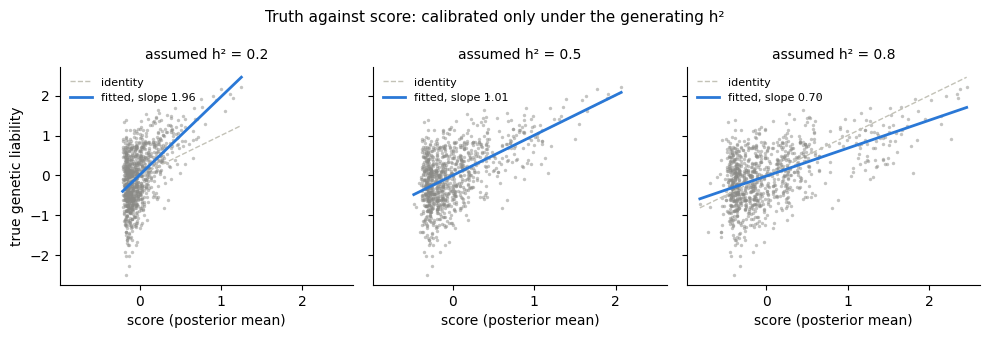

In [6]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(10, 3.4), sharex=True, sharey=True)
for ax, (h2_assumed, (e, slope)) in zip(axes, by_h2.items()):
    ax.scatter(e, cohort.genetic, s=6, color="#8a8a86", alpha=0.5, linewidths=0)
    grid = np.linspace(e.min(), e.max(), 2)
    ax.plot(grid, grid, color="#c3c2b7", lw=1, ls="--", label="identity")
    intercept = np.polyfit(e, cohort.genetic, 1)[1]
    ax.plot(grid, slope * grid + intercept, color="#2a78d6", lw=2,
            label=f"fitted, slope {slope:.2f}")
    ax.set_title(f"assumed h² = {h2_assumed}", fontsize=10)
    ax.set_xlabel("score (posterior mean)")
    ax.legend(frameon=False, fontsize=8, loc="upper left")
    for side in ("top", "right"):
        ax.spines[side].set_visible(False)
axes[0].set_ylabel("true genetic liability")
fig.suptitle("Truth against score: calibrated only under the generating h²", fontsize=11)
fig.tight_layout()

### Q3: Which columns moved and which did not? What does a slope of 1 mean, and why does only the right h² give it?

A posterior mean is *calibrated* when the truth regressed on it has slope 1: among
probands scored 0.3, the true liability averages 0.3. Relate your slopes to the
guide's advice on h². Optional: scatter `cohort.genetic` against the score for
each h² and draw the fitted line.

**Answer.** The correlation column stayed put; the three variance columns and the
slope moved. A posterior mean is calibrated by construction under its own model:
E[g | data] regressed on itself has slope 1, so among probands scored 0.3 the true
liability averages 0.3. Only the model with the right variance components is the
model the data came from. Under h² = 0.2 the scores are too timid, and the truth
moves twice as fast as the score; under 0.8 they are too bold.

A GWAS that uses the score as a phenotype is a ranking exercise and survives a
wrong h². Anything that reads the score's scale does not: the risk in Part B, a
comparison of scores across diseases, or the variance a polygenic score explains
in the family-history phenotype. That is why the guide asks for an external
liability-scale h², or a cross-check such as Part C.

## Part B. Who becomes a case between 40 and 70?

Step 4's answer says that its correlation of 0.31 "is not the accuracy of
predicting who becomes a case after 40". Measure that accuracy. The 974 probands in
`predicted` were disease-free at 40; an *incident* case is one of them diagnosed by
70, which the simulation knows through `cohort.onset`.

### Q4: How many of the 974 probands become incident cases, and what is the incidence?

Hint: `cohort.status` means "diagnosed by 70" and `at_risk` means "undiagnosed at
40". Combine them, then index with `at_risk` so that the result lines up with
`pred_est`.

In [7]:
y = (at_risk & cohort.status)[at_risk]
print(f"{int(y.sum())} incident cases among {len(y)} probands ({y.mean():.1%})")

71 incident cases among 974 probands (7.3%)


**Answer.** 71 incident cases among 974 probands, 7.3%. The ten people diagnosed
before 40 are not in `predicted`: step 4 excluded them because scoring a prevalent
case and calling it prospective is leakage.

### Q5: Compute the AUC for three predictors of that outcome on the same 974 people.

The AUC is the probability that a random incident case scores above a random
non-case. With ranks from `scipy.stats.rankdata` it is the Mann–Whitney statistic:
if `r` are the ranks of the predictor, `n1` the number of cases and `n0` the number
of non-cases, AUC = (sum of the cases' ranks − n1(n1 + 1)/2) / (n1 · n0).

The predictors: the prospective score `pred_est`; the true genetic liability
`cohort.genetic[at_risk]`, which is the ceiling for any predictor built from
genetics alone; and the step-3 score `est` restricted to the same people, which
used each proband's own diagnosis.

**Before running:** order the three AUCs.

In [8]:
def auc(x, y):
    r = rankdata(x)
    n1, n0 = y.sum(), (~y).sum()
    return (r[y].sum() - n1 * (n1 + 1) / 2) / (n1 * n0)

def auc_se(x, y):
    # Hanley & McNeil (1982) standard error
    a = auc(x, y)
    n1, n0 = y.sum(), (~y).sum()
    q1, q2 = a / (2 - a), 2 * a**2 / (1 + a)
    return np.sqrt((a * (1 - a) + (n1 - 1) * (q1 - a**2) + (n0 - 1) * (q2 - a**2)) / (n1 * n0))

for label, x in (("prospective score", pred_est),
                 ("true genetic liability", cohort.genetic[at_risk]),
                 ("step-3 score, same people", est[at_risk])):
    print(f"AUC {label:26s} = {auc(x, y):.3f} +/- {auc_se(x, y):.3f}")

AUC prospective score          = 0.612 +/- 0.037
AUC true genetic liability     = 0.866 +/- 0.028
AUC step-3 score, same people  = 0.994 +/- 0.007


**Checkpoint.** The step-3 score should sit near 1. If it does not, you have not
restricted it to the probands in `predicted`.

**Answer.** Leaked step-3 score 0.99, true genetic liability 0.87, prospective
score 0.61. With 71 events the standard error of an AUC near 0.6 is about 0.04
(Hanley–McNeil), so 0.61 against 0.87 is a real gap, and 0.61 against 0.5 is a
real signal.

### Q6: Why is the ceiling below 1 although it is the truth? Where does the gap between the prospective score and the ceiling come from? What does the third AUC say about `use="gwas"` in a prospective claim?

Use step 3's decomposition: of Var(g) = 0.5, the relatives and the proband's own
diagnosis identified about 0.15, and about 0.36 remained posterior uncertainty.

**Answer.** The outcome depends on the full liability g + e, and the residual e
has variance 1 − h² = 0.5 that no genetic quantity can see. Even perfect knowledge
of g predicts incident disease with an AUC of 0.87 here; a ceiling of 1 would need
h² = 1.

The prospective score knows g only through relatives. Step 3 said that, with the
proband's own diagnosis included, the data identified about 0.15 of Var(g) = 0.5
and left 0.36 as posterior uncertainty; step 4 identified less, without it. The
score is therefore a shrunken, noisy version of g, and its AUC sits at 0.61.

The third AUC, 0.99, is what leakage looks like. The step-3 score contains the
proband's own diagnosis, which is the outcome, so a "prospective" evaluation of
`use="gwas"` scores evaluates the outcome against itself. Step 4's `proband_state`
check exists to catch this.

### Q7: Turn the score into a risk and check it against the observed incidence.

A posterior mean liability is not a probability, but with its posterior variance
it becomes one. Under the model, a proband's full liability given the relatives is
Normal with mean `m = pred_est` and variance `s² = predicted.var + 1 − h²`: the
residual is independent of the relatives because `use="prediction"` hid the
proband's own status. With thresholds `T_a = Φ⁻¹(1 − CIP(a))`, being disease-free
at 40 means `l ≤ T40` and being diagnosed by 70 means `l > T70`, so

risk = [Φ((T40 − m)/s) − Φ((T70 − m)/s)] / Φ((T40 − m)/s).

Compute it for every proband. Compare the mean risk with the incidence from Q4.
Then split the probands into three equal-size groups by rank of `pred_est` and
compare observed incidence with mean risk in each group.

In [9]:
m, v = pred_est, np.asarray(predicted.var)
T40 = norm.ppf(1.0 - np.interp(INDEX_AGE, AGE_GRID, TRUE_CIP))
T70 = norm.ppf(1.0 - np.interp(EVAL_AGE, AGE_GRID, TRUE_CIP))
s = np.sqrt(v + 1.0 - H2)
p_free_at_40 = norm.cdf((T40 - m) / s)
risk = (p_free_at_40 - norm.cdf((T70 - m) / s)) / p_free_at_40

print(f"mean model risk {risk.mean():.4f}   observed incidence {y.mean():.4f}")

thirds = np.array_split(np.argsort(m, kind="stable"), 3)
for label, g in zip(("low", "middle", "high"), thirds):
    print(f"{label:>7}  n={len(g)}  observed {y[g].mean():.3f}  model risk {risk[g].mean():.3f}")

mean model risk 0.0732   observed incidence 0.0729
    low  n=325  observed 0.046  model risk 0.050
 middle  n=325  observed 0.086  model risk 0.066
   high  n=324  observed 0.086  model risk 0.104


**Checkpoint.** The mean model risk should agree with the observed incidence to
within a few tenths of a percent. Why does the risk need `predicted.var` and not
only the score? With 71 events, how many groups can this cohort support?

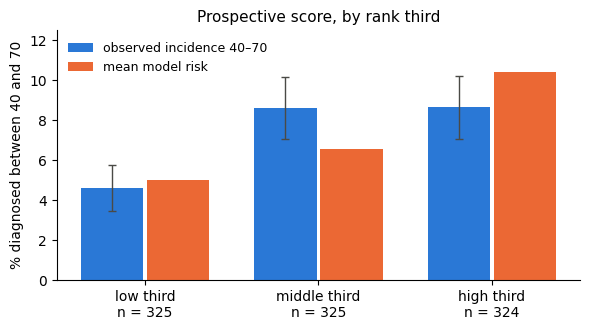

In [10]:
fig, ax = plt.subplots(figsize=(6, 3.4))
labels = ("low", "middle", "high")
obs = np.array([y[g].mean() for g in thirds])
mod = np.array([risk[g].mean() for g in thirds])
n = np.array([len(g) for g in thirds])
x = np.arange(3)
ax.bar(x - 0.19, 100 * obs, width=0.36, color="#2a78d6", label="observed incidence 40–70")
ax.errorbar(x - 0.19, 100 * obs, yerr=100 * np.sqrt(obs * (1 - obs) / n),
            fmt="none", ecolor="#4a4a46", elinewidth=1, capsize=3)
ax.bar(x + 0.19, 100 * mod, width=0.36, color="#eb6834", label="mean model risk")
ax.set_xticks(x, [f"{l} third\nn = {k}" for l, k in zip(labels, n)])
ax.set_ylim(0, 12.5)
ax.set_ylabel("% diagnosed between 40 and 70")
ax.set_title("Prospective score, by rank third", fontsize=11)
ax.legend(frameon=False, fontsize=9)
for side in ("top", "right"):
    ax.spines[side].set_visible(False)
fig.tight_layout()

**Answer.** Mean model risk 7.32% against an observed 7.29%: the
model's absolute risk is calibrated in the large, as it must be when the model
generated the data. By rank third the observed incidence is 4.6%, 8.6%
and 8.6%, against model risks of 5.0%, 6.6% and 10.4%.
Each third holds between 15 and 28 cases, so each observed proportion has a
standard error of 1.2 to 1.6 percentage points (the error bars): the lowest third
is separated from the rest, and nothing finer is. Three groups is what 71 events
support.

The risk needed `predicted.var` because two probands with the same score but a
different number of informative relatives have a different posterior spread, and
a wider spread pushes more probability past the threshold. That is why the scorer
returns a variance next to every mean. It is also where Part A comes back: s² uses
h² twice, once inside the posterior variance and once as 1 − h², so a wrong h²
produces a confidently wrong risk. ltpred's algorithm page relates this
construction to
[Sham's liability-threshold risk models](https://bvilhjal.github.io/ltpred/algorithm/#connection-to-shams-liability-threshold-risk-models).

## Part C. Get h² from the register itself (homework)

Part A showed that h² is not a nuisance parameter. The [method guide](https://bvilhjal.github.io/ltpred/guide/)
suggests a cross-check: h² is about twice a first-degree tetrachoric correlation,
and `ltpred.tetrachoric` estimates one from the 2×2 table of two binary statuses.

### Q8: Estimate h² from parent–offspring pairs in the tutorial register, then in a larger one.

Pair every person with each parent whose id is in the table (both parents give a
pair) and call `tetrachoric(parent_status, child_status)`. Report 2ρ ± 2 SE. Then
simulate a register with `n_founder_pairs=1000` and seed 1 for both generators and
repeat. Stay at or below 1000 founder pairs on a laptop: the simulator factorises
the full kinship matrix.

In [11]:
from ltpred.tetrachoric import tetrachoric


def parent_offspring_status(reg):
    idx = {p: i for i, p in enumerate(reg.ids)}
    parent, child = [], []
    for kid, fa, mo in zip(reg.ids, reg.father, reg.mother):
        for par in (fa, mo):
            if par in idx:

                parent.append(reg.status[idx[par]])
                child.append(reg.status[idx[kid]])
    return np.asarray(parent), np.asarray(child)


def report(label, reg):
    par, kid = parent_offspring_status(reg)
    t = tetrachoric(par, kid)
    print(f"{label}: {len(reg.ids)} people, {int(reg.status.sum())} diagnosed; "
          f"{len(par)} pairs, {int((par & kid).sum())} both diagnosed")
    print(f"    rho = {t.rho:+.3f} +/- {t.se:.3f}  ->  h2 = {2 * t.rho:+.2f} +/- {2 * t.se:.2f}"
          f"   (truth {H2})")


report("tutorial register", cohort)

big_ids, big_fa, big_mo = simulate_pedigree(
    np.random.default_rng(1), n_founder_pairs=1000, gens=2)
big = simulate_register_liabilities(
    np.random.default_rng(1), big_ids, big_fa, big_mo,
    h2=H2, cip_ages=AGE_GRID, cip_values=TRUE_CIP, eval_age=EVAL_AGE)
report("larger register  ", big)

tutorial register: 984 people, 81 diagnosed; 1528 pairs, 20 both diagnosed
    rho = +0.237 +/- 0.074  ->  h2 = +0.47 +/- 0.15   (truth 0.5)


larger register  : 10159 people, 743 diagnosed; 15852 pairs, 185 both diagnosed
    rho = +0.250 +/- 0.024  ->  h2 = +0.50 +/- 0.05   (truth 0.5)


**Checkpoint.** Both estimates should bracket 0.5, the second with about a third
of the first's standard error.

**Answer.** The tutorial register gives h² = 0.47 ± 0.15. It has 1528 pairs, but
only the 20 pairs in which both are diagnosed carry the information, so this
cohort cannot pin its own h². Ten times the people give ten times the pairs and a
third of the standard error: 0.50 ± 0.05.

### Q9: Why does twice the tetrachoric work here, and what would break it in a real register?

Consider what the tetrachoric assumes about the threshold, what this simulation
assumes about shared environment, and how the register was sampled.

**Answer.** Twice the parent–offspring tetrachoric estimates h² when three things
hold. First, both statuses are dichotomised at one common threshold; that holds
here because everyone is followed to 70 and status means "diagnosed by 70".
Second, the parent–offspring liability covariance is h²/2 and nothing else; that
holds because this simulation has no shared environment and no assortative mating.
Third, the pairs are a population sample.

A real register breaks the first assumption first: people have different
follow-up ages and birth cohorts, so one status column mixes thresholds. That is
the problem the age- and cohort-specific thresholds of LT-FH++ solve, and the
reason step 2 of the tutorial estimated an incidence curve. Shared environment
inflates 2ρ; a sibling tetrachoric would show it, and ltpred's fitters model it as
a `C` component. Case-enriched sampling changes the marginal case rates and biases
the thresholds unless the design is declared, which is why `fit_heritability`
demands a sampling contract.

### Q10: Analysis note.

In at most 150 words, state what the family-history score estimates, what it
showed in this exercise, and what it cannot establish. Cite one number from each
of Parts A and B and, if you did it, Part C.

**Answer (model note).** The family-history score is the posterior mean of a
proband's additive genetic liability given the relatives' diagnoses and ages, the
disease's incidence curve, and a liability-scale h². In this register it correlated
0.55 with the true liability when the proband's own diagnosis was used and 0.31
when it was hidden. Its scale is set by the model: told h² = 0.8 instead of 0.5,
the ranking held (correlation 0.54) while the calibration slope fell from 1.0 to
0.7 (Part A). As a predictor of who is diagnosed between 40 and 70 it reached an
AUC of 0.61 against a genetic ceiling of 0.87, and it became a calibrated absolute
risk only once its posterior variance was used (Part B). A register following
everyone to the same age recovered h² = 0.50 ± 0.05 from parent–offspring pairs
(Part C). The score is not a risk, cannot supply its own h², and its prospective
accuracy is not its correlation with liability.

## Environment

In [12]:
import platform, scipy
print(f"Python {platform.python_version()}  NumPy {np.__version__}  "
      f"SciPy {scipy.__version__}  ltpred {ltpred.__version__}")

Python 3.10.20  NumPy 1.26.4  SciPy 1.15.3  ltpred 0.7.0


---
Part of [ATIG 2026](https://github.com/bvilhjal/ATIG_2026), teaching day
[24 September](https://github.com/bvilhjal/ATIG_2026/tree/main/teaching_days/2026-09-24).